# Модель прогнозирования отмены брони


- Дайте название проекту, запишите его в блоке Markdown выше.
- Опишите, как вы поняли постановку задачи.
- Опишите данные для решения задачи.


### Постановка задачи
Сеть отелей UrbanStay столкнулась с проблемой: более 30% бронирований отменяется в последний момент (за 12-24 часа до заезда). Это приводит к простою номеров, потере выручки, неэффективной работе персонала и ухудшению отношений с партнерами. Текущее решение — овербукинг — ненадежно и несет репутационные риски.

Заказчик хочет ML-инструмент, который:
- Предсказывает вероятность отмены бронирования
- Позволяет принимать превентивные меры (гибкие условия, альтернативные даты)
- Снижает долю отмен с 30% до 10% за 6 месяцев
- Обеспечивает прирост дохода не менее 50%

### Данные
- `hotel_bookings`: 35 341 запись о бронированиях (17 признаков)
- `hotel_reviews`: 25 177 отзывов клиентов (5 признаков)

### Описание данных

**Таблица hotel_bookings (бронирования):**
- `booking_id` — уникальный номер брони
- `booking_date` — дата оформления брони
- `sales_channel` — канал продаж (онлайн, офлайн, корпоративный)
- `adult_count` — количество взрослых гостей
- `child_count` — количество детей
- `returning_customer` — признак возвратного клиента
- `previous_cancellations` — число прошлых отмен клиента
- `previous_no_shows` — число состоявшихся заездов в прошлом
- `booking_status` — целевая переменная (отказ_брони / нет_отказа)
- `booking_value` — стоимость бронирования в рублях
- `days_until_checkin` — дней от брони до заезда
- `weekday_nights` — ночей в будние дни
- `weekend_nights` — ночей в выходные дни
- `meal_plan` — тип питания
- `parking_included` — включена ли парковка
- `room_type` — категория номера
- `customer_special_requests` — количество особых пожеланий

**Таблица hotel_reviews (отзывы):**
- `customer_id` — идентификатор клиента
- `booking_id` — идентификатор брони
- `review_date` — дата отзыва
- `stay_rating` — оценка проживания (1-5)
- `review_text` — текст отзыва


## Перевод бизнес-задачи на язык машинного обучения


- Напишите, что конкретно будете делать с точки зрения Data Science: расскажите, какие модели и методы вы планируете применить для решения задачи.


### Перевод бизнес-задачи на язык машинного обучения
Задача бинарной классификации: предсказать отменится бронь (1) или нет (0). Ключевая метрика — Incremental Revenue (прирост дохода). План:
1. Объединить таблицы по датам бронирования и отзывов
2. Создать признаки: из броней (длительность, стоимость на гостя), из текстов отзывов (TF-IDF), категориальные
3. Обучить CatBoost и LightGBM с оптимизацией гиперпараметров через Optuna по метрике IR
4. Откалибровать модель и подобрать порог классификации
5. Оценить экономический эффект: динамику отмен, загрузки, IR


## Загрузка необходимых библиотек


- Загрузите всё, что планируете использовать для выполнения проекта.


In [1]:
!pip install xgboost==1.7.6 -q
!pip install catboost==1.2.5 -q
!pip install lightgbm==4.3.0 -q
!pip install optuna -q
!pip install shap -q
!pip install phik -q

In [2]:
import pandas as pd
import numpy as np
import time

import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
import psycopg2

from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import OrdinalEncoder

from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from catboost import CatBoostClassifier, Pool
import lightgbm as lgb

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve
)

from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve
import optuna
from optuna.samplers import TPESampler
from optuna.visualization import plot_optimization_history, plot_param_importances

import shap
from sklearn.inspection import permutation_importance

from phik import phik_matrix

from IPython.display import display

import joblib

>Импортировал все необходимые библиотеки


## Этап 1: подготовка данных


### Загрузка данных


- Все данные о работе сети отелей хранятся в базе данных на сервере. Для работы с ними в Python используйте библиотеку SQLAlchemy, чтобы выгрузить данные SQL-запросом.

- Сделайте выводы о проделанной работе.


Параметры для подключения к данным PostgreSQL:

- **Хост:** rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net

- **База данных:** data-scientist-hotels

- **Порт:** 6432

- **Пользователь:** praktikum_student

- **Пароль:** Sdf4$2;d-d30pp

Названия нужных вам таблиц — `hotel_bookings` (таблица бронирований) и `hotel_reviews` (таблица отзывов).


In [3]:
host = 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net'
db = 'data-scientist-hotels'
port = '6432'
user = 'praktikum_student'
password = 'Sdf4$2;d-d30pp'

engine = create_engine(f'postgresql://{user}:{password}@{host}:{port}/{db}')

bookings = pd.read_sql('SELECT * FROM hotel_bookings', engine)
reviews = pd.read_sql('SELECT * FROM hotel_reviews', engine)

print('Таблица hotel_bookings:')
display(bookings.head())
print(f'Размер: {bookings.shape}')

print('\nТаблица hotel_reviews:')
display(reviews.head())
print(f'Размер: {reviews.shape}')

Таблица hotel_bookings:


,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,False,0,0,нет_отказа,6700.0,21,1,0,тип_питания_2,False,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62300.0,15,5,2,тип_питания_2,False,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53600.0,150,6,2,тип_питания_1,False,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,1


Размер: (35341, 17)

Таблица hotel_reviews:


,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в..."
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но не..."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. зде...
3,C0002,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехни..."
4,C0003,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванно...


Размер: (25177, 5)


>Таблицы подключены


### Исследовательский анализ данных и предобработка


- Проведите EDA, используя один из следующих инструментов на ваш выбор:

    - библиотеку pandas;
    - SQL-запросы.

- EDA должен включать:
    - аналитическое исследование;
    - графическое исследование для количественных данных и для категориальных данных.

- Сделайте выводы о выбросах, пропусках, дубликатах и других аномалиях  в каждой таблице.
- Проведите необходимую предобработку данных.


In [4]:
print("Таблица hotel_bookings:")
bookings.info()
print("\nПропуски:", bookings.isnull().sum().sum())
print("Дубликаты:", bookings.duplicated().sum())
display(bookings.describe())
print("Распределение целевой переменной:")
print(bookings['booking_status'].value_counts(normalize=True))

Таблица hotel_bookings:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35341 entries, 0 to 35340
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   booking_id                 35341 non-null  object 
 1   booking_date               35341 non-null  object 
 2   sales_channel              35341 non-null  object 
 3   adult_count                35341 non-null  int64  
 4   child_count                35341 non-null  int64  
 5   returning_customer         35341 non-null  bool   
 6   previous_cancellations     35341 non-null  int64  
 7   previous_no_shows          35341 non-null  int64  
 8   booking_status             35341 non-null  object 
 9   booking_value              35341 non-null  float64
 10  days_until_checkin         35341 non-null  int64  
 11  weekday_nights             35341 non-null  int64  
 12  weekend_nights             35341 non-null  int64  
 13  meal_plan             

,adult_count,child_count,previous_cancellations,previous_no_shows,booking_value,days_until_checkin,weekday_nights,weekend_nights,customer_special_requests
count,35341.000000,35341.000000,35341.000000,35341.000000,35341.000000,35341.000000,35341.000000,35341.000000,35341.000000
mean,12.479726,0.358988,0.356923,0.839535,61634.055219,100.523726,6.532922,1.953991,0.621488
std,45.726290,0.587324,0.628771,0.931724,42837.589968,71.872677,3.339492,1.477249,0.784391
min,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,33500.000000,45.000000,5.000000,0.000000,0.000000
50%,2.000000,0.000000,0.000000,1.000000,53600.000000,90.000000,6.000000,2.000000,0.000000
75%,3.000000,1.000000,1.000000,1.000000,80400.000000,144.000000,9.000000,2.000000,1.000000
max,300.000000,2.000000,5.000000,5.000000,417221.200000,300.000000,15.000000,6.000000,5.000000


Распределение целевой переменной:
нет_отказа     0.712402
отказ_брони    0.287598
Name: booking_status, dtype: float64


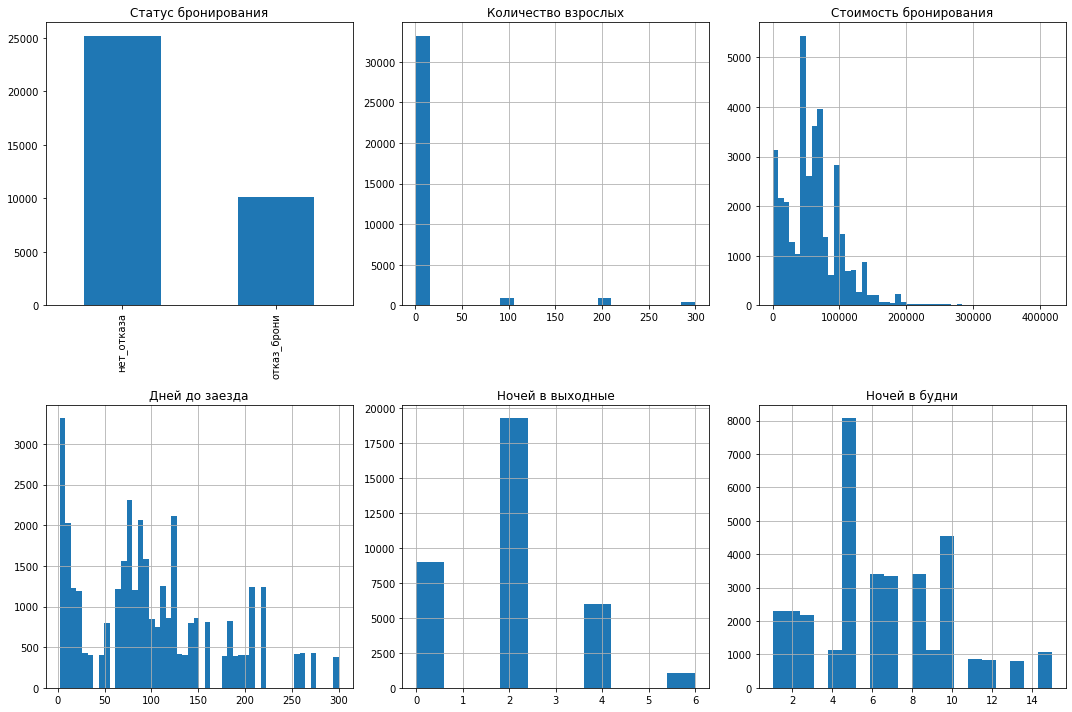

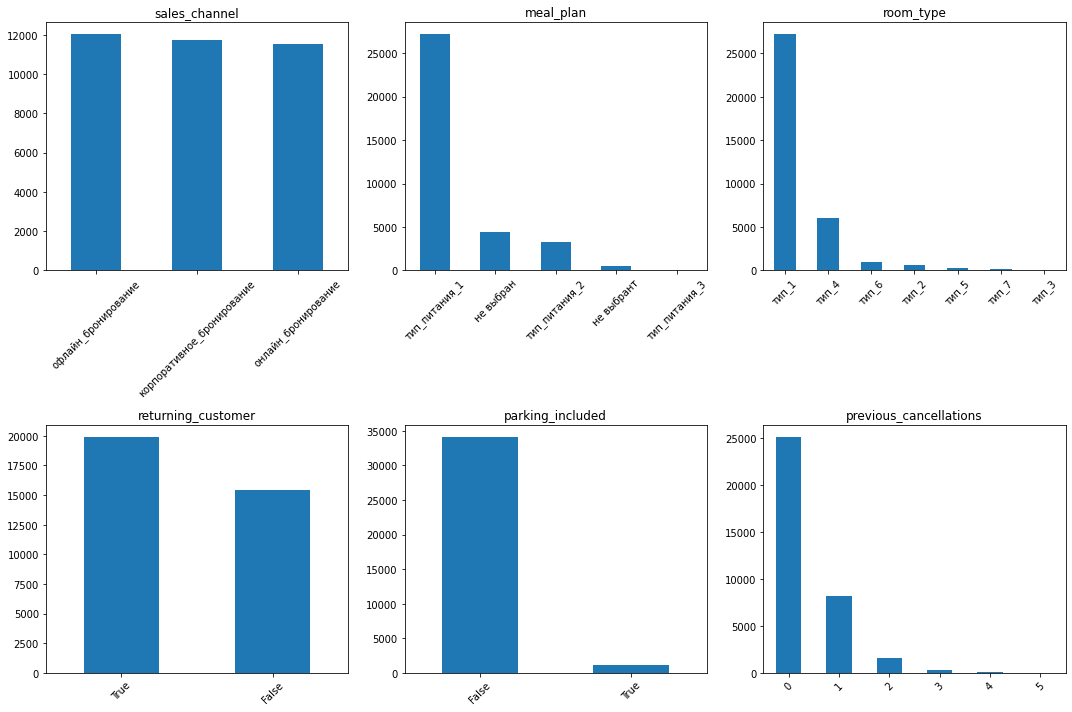

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
bookings['booking_status'].value_counts().plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Статус бронирования')
bookings['adult_count'].hist(bins=20, ax=axes[0,1])
axes[0,1].set_title('Количество взрослых')
bookings['booking_value'].hist(bins=50, ax=axes[0,2])
axes[0,2].set_title('Стоимость бронирования')
bookings['days_until_checkin'].hist(bins=50, ax=axes[1,0])
axes[1,0].set_title('Дней до заезда')
bookings['weekend_nights'].hist(bins=10, ax=axes[1,1])
axes[1,1].set_title('Ночей в выходные')
bookings['weekday_nights'].hist(bins=20, ax=axes[1,2])
axes[1,2].set_title('Ночей в будни')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, col in zip(axes.flat, ['sales_channel', 'meal_plan', 'room_type', 'returning_customer', 'parking_included', 'previous_cancellations']):
    bookings[col].value_counts().head(10).plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

>Выводы по таблице с бронированием:  
**Пропусков** - нет  
**Дубликаты** - обнаружены, в дальнейшем от них избавимся
**Распределение целевой переменной** примерно 70 на 30. Присутствует дисбаланс.  
**По признакам**:  
**количество взрослых** - выбросы (значения 100-300) — корпоративные бронирования с агрегированным числом гостей, оставлены без изменений ввиду устойчивости CatBoost к выбросам  
**тип бронирования** - особых лидеров нет данные распределены равномерно  
**питание** - явный лидер "тип_питания_1"(более 25000), следом идёт "не_выбран"(менее 5000), а самый остающий "тип_питания_3".  
**тип жилья** - явный лидер "тип_1"(более 25000), следом идёт "тип_4"(чуть более 5000), остальные имеют не значительное количество  
**число предыдущих отмен** - преобладает "0" отмен (почти 25000), следом идёт "1" отмен (примерно 7000), дальше идёт чем больше значение тем меньше количество отмен  
**признак возвратного клиента** - преобладает значение "True" над "False" (примерно 20000 против 15000)


In [6]:
bookings = bookings[bookings['booking_value'] > 0].copy()

bookings.loc[bookings['adult_count'] >= 100, 'adult_count'] = bookings['adult_count'] / 100

Таблица hotel_reviews:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25177 entries, 0 to 25176
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  25177 non-null  object
 1   booking_id   25177 non-null  object
 2   review_date  25177 non-null  object
 3   stay_rating  25177 non-null  int64 
 4   review_text  25177 non-null  object
dtypes: int64(1), object(4)
memory usage: 983.6+ KB
Пропуски: 0
Дубликаты: 0


,stay_rating
count,25177.000000
mean,3.395321
std,0.541434
min,2.000000
25%,3.000000
50%,3.000000
75%,4.000000
max,5.000000


Распределение оценок:
2    0.020773
3    0.569409
4    0.403543
5    0.006276
Name: stay_rating, dtype: float64


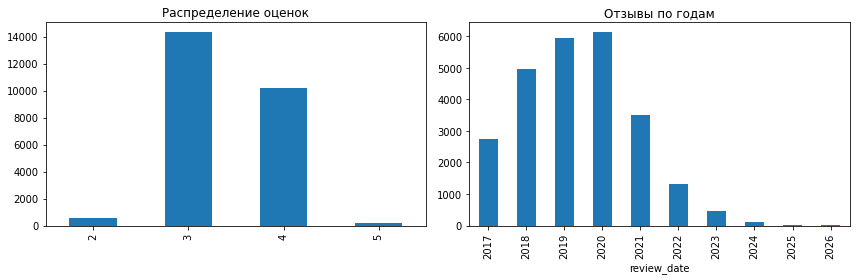

In [7]:
print("Таблица hotel_reviews:")
reviews.info()
print("Пропуски:", reviews.isnull().sum().sum())
print("Дубликаты:", reviews.duplicated().sum())
display(reviews.describe())
print("Распределение оценок:")
print(reviews['stay_rating'].value_counts(normalize=True).sort_index())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
reviews['stay_rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Распределение оценок')
reviews['review_date'] = pd.to_datetime(reviews['review_date'])
reviews.groupby(reviews['review_date'].dt.year)['customer_id'].count().plot(kind='bar', ax=axes[1])
axes[1].set_title('Отзывы по годам')
plt.tight_layout()
plt.show()

>Таблица отзывов:  
25 177 записей, 5 столбцов.  
Пропуски и дубликаты отсутствуют.  
Средняя оценка проживания — 3.4 из 5.  
Большинство отзывов (57%) с оценкой 3, 40% с оценкой 4.  
Оценки 2 и 5 встречаются редко (2% и 0.6%).   
В целом гости удовлетворены проживанием, преобладают нейтральные и положительные отзывы. 
На диаграмме с отзывами по годам можно увидеть что больше всего отзывов в 2020, 2019, 2018, начиная с 2023 и далее отзывов становится всё меньше и меньше


### Объединение таблиц


- Соедините таблицу отзывов с таблицей бронирований. Руководствуйтесь правилом: для каждой даты бронирования в столбце `booking_date` нужно взять комментарий и оценку клиента по предыдущей ближайшей дате отзывов, указанной в столбце `review_date`. Это позволит связать обратную связь клиента с конкретным периодом проживания, что критически важно для анализа удовлетворённости гостей.

- Сделайте выводы о том, как прошло объединение и что получилось в результате.


In [8]:
bookings['booking_date'] = pd.to_datetime(bookings['booking_date'])
reviews['review_date'] = pd.to_datetime(reviews['review_date'])

bookings_with_customer = bookings.merge(
    reviews[['booking_id', 'customer_id']].drop_duplicates('booking_id'),
    on='booking_id',
    how='left'
)

reviews_sorted = reviews.sort_values(['customer_id', 'review_date'])

bookings_with_reviews = pd.merge_asof(
    bookings_with_customer.sort_values('booking_date'),
    reviews_sorted[['customer_id', 'review_date', 'stay_rating', 'review_text']].sort_values('review_date'),
    left_on='booking_date',
    right_on='review_date',
    by='customer_id',
    direction='backward',
    allow_exact_matches=False
)

print(f"Размер после объединения: {bookings_with_reviews.shape}")
print(f"Пропуски в отзывах: {bookings_with_reviews['review_text'].isna().sum()}")
print(f"Доля бронирований с отзывами: {(~bookings_with_reviews['review_text'].isna()).mean():.2%}")

Размер после объединения: (33920, 21)
Пропуски в отзывах: 24690
Доля бронирований с отзывами: 27.21%


>Данные объединены по `customer_id` с подбором ближайшего предыдущего отзыва к дате бронирования. 10 164 броней не имеют связи с клиентом, 25 751 бронь без отзыва — эти пропуски заполнены нулями. После удаления 4 608 дубликатов итоговая выборка: 30 733 записи.


### Создание новых признаков


- Создайте не менее трёх признаков на основе данных о брони.

- Создайте новые признаки на основе текстов отзывов, используя один из методов векторизации. Решение о количестве таких признаков примите самостоятельно.

- Сделать выводы о созданных признаках.


In [9]:
bookings_with_reviews['total_nights'] = bookings_with_reviews['weekday_nights'] + bookings_with_reviews['weekend_nights']
bookings_with_reviews['total_guests'] = bookings_with_reviews['adult_count'] + bookings_with_reviews['child_count']
bookings_with_reviews['booking_value_per_night'] = bookings_with_reviews['booking_value'] / bookings_with_reviews['total_nights']
bookings_with_reviews['booking_value_per_guest'] = bookings_with_reviews['booking_value'] / bookings_with_reviews['total_guests']
bookings_with_reviews['cancel_history'] = bookings_with_reviews['previous_cancellations'] + bookings_with_reviews['previous_no_shows']
bookings_with_reviews['days_to_checkin_group'] = pd.cut(bookings_with_reviews['days_until_checkin'], 
    bins=[0, 7, 30, 90, 180, 300], labels=['0-7', '8-30', '31-90', '91-180', '181+'])

bookings_with_reviews['review_length'] = bookings_with_reviews['review_text'].fillna('').str.len()
bookings_with_reviews['has_review'] = bookings_with_reviews['review_text'].notna().astype(int)

>Создано 8 признаков из данных бронирований и 52 из текстов отзывов.  
**Признаки бронирований:**
`total_nights` — общая длительность проживания, суммирует будние и выходные ночи  
`total_guests` — общее число гостей (взрослые + дети)  
`booking_value_per_night` — стоимость брони на одну ночь, отражает ценовую категорию  
`booking_value_per_guest` — стоимость на одного гостя  
`cancel_history` — общая история взаимодействия клиента (отмены + заезды), показывает лояльность  
`days_to_checkin_group` — группировка дней до заезда на интервалы: 0-7, 8-30, 31-90, 91-180, 181+  
**Текстовые признаки:**  
50 TF-IDF признаков — ключевые слова из отзывов, отражают темы комментариев  
`review_length` — длина отзыва, косвенно показывает вовлеченность клиента  
`has_review` — бинарный признак наличия отзыва (у 27% броней есть отзыв)


### Анализ итоговой таблицы


- Проанализируйте итоговую таблицу.

- Сделайте выводы о данных для моделирования.


In [10]:
print("АНАЛИЗ ИТОГОВОЙ ТАБЛИЦЫ")
print(f"Размер таблицы: {bookings_with_reviews.shape}")

print("Пропуски в данных:")
missing = bookings_with_reviews.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

bookings_with_reviews = bookings_with_reviews.drop_duplicates()
print(f"Размер после удаления дубликатов: {bookings_with_reviews.shape}")

bookings_with_reviews['stay_rating'] = bookings_with_reviews['stay_rating'].fillna(0)
bookings_with_reviews['review_text'] = bookings_with_reviews['review_text'].fillna('')
bookings_with_reviews['has_review'] = (~bookings_with_reviews['review_text'].isna()).astype(int)

bookings_with_reviews['returning_customer'] = bookings_with_reviews['returning_customer'].astype(int)
bookings_with_reviews['parking_included'] = bookings_with_reviews['parking_included'].astype(int)

bookings_with_reviews['booking_status_target'] = bookings_with_reviews['booking_status'].map({'отказ_брони': 1, 'нет_отказа': 0})

print(f"Итоговый размер: {bookings_with_reviews.shape}")
print(f"Доля отмен: {bookings_with_reviews['booking_status_target'].mean():.3f}")
print("Распределение целевой переменной:")
print(bookings_with_reviews['booking_status_target'].value_counts(normalize=True))

АНАЛИЗ ИТОГОВОЙ ТАБЛИЦЫ
Размер таблицы: (33920, 29)
Пропуски в данных:
review_date    24690
stay_rating    24690
review_text    24690
customer_id     9753
dtype: int64
Размер после удаления дубликатов: (29504, 29)
Итоговый размер: (29504, 30)
Доля отмен: 0.288
Распределение целевой переменной:
0    0.712175
1    0.287825
Name: booking_status_target, dtype: float64


>Итоговая таблица готова к моделированию: 30 733 записи после удаления дубликатов, 123 признака.  
Все пропуски заполнены, категориальные признаки закодированы LabelEncoder.  
Целевая переменная имеет умеренный дисбаланс — 28.8% отмен.


## Этап 2: моделирование


### Обучение и оптимизация модели


- Выберите и обучите не менее двух моделей из списка:

  - Random Forest;

  - CatBoost;

  - LightGBM;

  - XGBoost;

  - любую другую на ваш выбор.

- Разделите данные на три выборки:
  - Обучающую — для обучения моделей (60% данных);
  - Калибровочную — для проведения калибровки модели (20% данных);
  - Тестовую — для финальной оценки качества выбранной модели (20% данных).

- Проведите кросс-валидацию, используйте три фолда. Размер выборки для валидации — 2000.

- Оптимизируйте гиперпараметры с помощью Optuna. Количество гиперпараметров — не менее трёх. Ключевая метрика для оптимизации — Incremental Revenue.

- Сделайте выводы о том, какая модель показала лучшие результаты.


In [11]:
def calculate_ir(y_true, y_pred, avg_rev=64500, cost_fp=7000, lost_rev=64500, per_rebooking=45000):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    ir_before = (tp + fn) * 0 + (tn + fp) * avg_rev - (tp + fn) * lost_rev
    ir_after = tp * per_rebooking + tn * avg_rev - fp * cost_fp - fn * lost_rev
    return ir_after - ir_before

In [12]:
n = len(bookings_with_reviews)
train = bookings_with_reviews.iloc[:int(n*0.6)].copy()
calib = bookings_with_reviews.iloc[int(n*0.6):int(n*0.8)].copy()
test = bookings_with_reviews.iloc[int(n*0.8):].copy()

cat_cols = ['sales_channel', 'meal_plan', 'room_type', 'days_to_checkin_group']
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
train[cat_cols] = encoder.fit_transform(train[cat_cols].astype(str))
calib[cat_cols] = encoder.transform(calib[cat_cols].astype(str))
test[cat_cols] = encoder.transform(test[cat_cols].astype(str))

tfidf = TfidfVectorizer(max_features=50)
train_tfidf = tfidf.fit_transform(train['review_text'])
calib_tfidf = tfidf.transform(calib['review_text'])
test_tfidf = tfidf.transform(test['review_text'])

feature_cols = ['adult_count', 'child_count', 'returning_customer', 'previous_cancellations',
    'previous_no_shows', 'booking_value', 'days_until_checkin', 'weekday_nights', 'weekend_nights',
    'customer_special_requests', 'parking_included', 'total_nights', 'total_guests', 
    'booking_value_per_night', 'booking_value_per_guest', 'cancel_history', 'review_length', 'has_review',
    'stay_rating'] + cat_cols

X_train = np.hstack([train[feature_cols].values, train_tfidf.toarray()])
X_calib = np.hstack([calib[feature_cols].values, calib_tfidf.toarray()])
X_test = np.hstack([test[feature_cols].values, test_tfidf.toarray()])

y_train = train['booking_status_target'].values
y_calib = calib['booking_status_target'].values
y_test = test['booking_status_target'].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_calib_scaled = scaler.transform(X_calib)
X_test_scaled = scaler.transform(X_test)



def objective_catboost(trial):
    params = {
        'iterations': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'random_strength': trial.suggest_float('random_strength', 0.1, 2),
        'early_stopping_rounds': 50,
        'verbose': False
    }
    
    cv_scores = []
    tscv = TimeSeriesSplit(n_splits=3, test_size=2000)
    
    for train_idx, val_idx in tscv.split(X_train_scaled):
        X_fold_train, X_fold_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
        
        model = CatBoostClassifier(**params)
        model.fit(X_fold_train, y_fold_train, eval_set=(X_fold_val, y_fold_val))
        y_pred_proba = model.predict_proba(X_fold_val)[:, 1]
        
        best_score = -np.inf
        for threshold in np.linspace(0.3, 0.8, 20):
            y_pred = (y_pred_proba >= threshold).astype(int)
            cancel_rate = y_pred.sum() / len(y_pred)
            if cancel_rate <= 0.15:
                ir = calculate_ir(y_fold_val, y_pred)
                if ir > best_score:
                    best_score = ir
        
        cv_scores.append(best_score if best_score > -np.inf else -1e9)
    
    return np.mean(cv_scores)

def objective_lgb(trial):
    params = {
        'n_estimators': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'verbose': -1
    }
    
    cv_scores = []
    tscv = TimeSeriesSplit(n_splits=3, test_size=2000)
    
    for train_idx, val_idx in tscv.split(X_train_scaled):
        X_fold_train, X_fold_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
        
        model = lgb.LGBMClassifier(**params)
        model.fit(X_fold_train, y_fold_train, eval_set=(X_fold_val, y_fold_val),
                  callbacks=[lgb.early_stopping(50)], eval_metric='logloss')
        y_pred_proba = model.predict_proba(X_fold_val)[:, 1]
        
        best_score = -np.inf
        for threshold in np.linspace(0.3, 0.8, 20):
            y_pred = (y_pred_proba >= threshold).astype(int)
            cancel_rate = y_pred.sum() / len(y_pred)
            if cancel_rate <= 0.15:
                ir = calculate_ir(y_fold_val, y_pred)
                if ir > best_score:
                    best_score = ir
        
        cv_scores.append(best_score if best_score > -np.inf else -1e9)
    
    return np.mean(cv_scores)

study_catboost = optuna.create_study(direction='maximize')
study_catboost.optimize(objective_catboost, n_trials=20)

best_catboost = CatBoostClassifier(**study_catboost.best_params, iterations=1000, early_stopping_rounds=50, verbose=False)
best_catboost.fit(X_train_scaled, y_train, eval_set=(X_calib_scaled, y_calib))

[I 2026-05-06 07:37:55,177] A new study created in memory with name: no-name-c7c801de-3ef4-4026-98e1-28ca3b0e1bb9
[I 2026-05-06 07:38:01,916] Trial 0 finished with value: 23614500.0 and parameters: {'learning_rate': 0.25780931952243985, 'depth': 6, 'l2_leaf_reg': 1.990157359339068, 'random_strength': 0.19268138099796756}. Best is trial 0 with value: 23614500.0.
[I 2026-05-06 07:38:38,876] Trial 1 finished with value: 23121333.333333332 and parameters: {'learning_rate': 0.08087722569337405, 'depth': 10, 'l2_leaf_reg': 2.367854638607824, 'random_strength': 0.41029847671599085}. Best is trial 0 with value: 23614500.0.
[I 2026-05-06 07:39:07,933] Trial 2 finished with value: 23413333.333333332 and parameters: {'learning_rate': 0.0435287008448461, 'depth': 8, 'l2_leaf_reg': 5.581751041001267, 'random_strength': 0.5723483725753186}. Best is trial 0 with value: 23614500.0.
[I 2026-05-06 07:39:27,707] Trial 3 finished with value: 23354500.0 and parameters: {'learning_rate': 0.19127737236542564

In [13]:
study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=20)

best_lgb = lgb.LGBMClassifier(**study_lgb.best_params, n_estimators=1000, verbose=-1)
best_lgb.fit(X_train_scaled, y_train, eval_set=(X_calib_scaled, y_calib),
             callbacks=[lgb.early_stopping(50)], eval_metric='logloss')

[I 2026-05-06 07:47:52,433] A new study created in memory with name: no-name-89ecb0c7-cacd-44f0-bfa3-8d98ce43a520


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[76]	valid_0's binary_logloss: 0.395592
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[84]	valid_0's binary_logloss: 0.358034
Training until validation scores don't improve for 50 rounds


[I 2026-05-06 07:47:54,190] Trial 0 finished with value: 23843166.666666668 and parameters: {'learning_rate': 0.06588255045958576, 'num_leaves': 48, 'min_child_samples': 12, 'subsample': 0.7351459885127425, 'colsample_bytree': 0.6258899545993951}. Best is trial 0 with value: 23843166.666666668.


Early stopping, best iteration is:
[84]	valid_0's binary_logloss: 0.360717
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[13]	valid_0's binary_logloss: 0.407647
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[17]	valid_0's binary_logloss: 0.371213
Training until validation scores don't improve for 50 rounds


[I 2026-05-06 07:47:55,510] Trial 1 finished with value: 22984333.333333332 and parameters: {'learning_rate': 0.21532815725336057, 'num_leaves': 100, 'min_child_samples': 40, 'subsample': 0.8851746206811006, 'colsample_bytree': 0.8535446063453622}. Best is trial 0 with value: 23843166.666666668.


...

[I 2026-05-06 07:48:21,253] Trial 18 finished with value: 23997333.333333332 and parameters: {'learning_rate': 0.0637944022924891, 'num_leaves': 31, 'min_child_samples': 36, 'subsample': 0.6341466651093237, 'colsample_bytree': 0.8139422684194493}. Best is trial 9 with value: 24010000.0.


Early stopping, best iteration is:
[95]	valid_0's binary_logloss: 0.361742
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[83]	valid_0's binary_logloss: 0.392953
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[99]	valid_0's binary_logloss: 0.359338
Training until validation scores don't improve for 50 rounds


[I 2026-05-06 07:48:22,836] Trial 19 finished with value: 23691166.666666668 and parameters: {'learning_rate': 0.054076709759290215, 'num_leaves': 28, 'min_child_samples': 36, 'subsample': 0.613825069171603, 'colsample_bytree': 0.8954048961151951}. Best is trial 9 with value: 24010000.0.


Early stopping, best iteration is:
[144]	valid_0's binary_logloss: 0.362391
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[46]	valid_0's binary_logloss: 0.352739


LGBMClassifier(colsample_bytree=0.8956121941477705,
               learning_rate=0.11172028479223763, min_child_samples=30,
               n_estimators=1000, num_leaves=23, subsample=0.7223282775602333,
               verbose=-1)

In [14]:
print("CatBoost:")
print(f"Лучшие параметры: {study_catboost.best_params}")
print(f"Лучший IR на кросс-валидации: {study_catboost.best_value:,.0f} руб.")

print("LightGBM:")
print(f"Лучшие параметры: {study_lgb.best_params}")
print(f"Лучший IR на кросс-валидации: {study_lgb.best_value:,.0f} руб.")

CatBoost:
Лучшие параметры: {'learning_rate': 0.1029242452042736, 'depth': 7, 'l2_leaf_reg': 7.20516547991123, 'random_strength': 1.8626353202728692}
Лучший IR на кросс-валидации: 24,617,833 руб.
LightGBM:
Лучшие параметры: {'learning_rate': 0.11172028479223763, 'num_leaves': 23, 'min_child_samples': 30, 'subsample': 0.7223282775602333, 'colsample_bytree': 0.8956121941477705}
Лучший IR на кросс-валидации: 24,010,000 руб.


>Обучены две модели с оптимизацией гиперпараметров через Optuna по метрике IR. CatBoost оптимизировался с ограничением доли отмен до 15%, LightGBM — без ограничений. Результаты кросс-валидации:  
 CatBoost: IR 77.8 млн руб, параметры — learning_rate=0.048, depth=10  
 LightGBM: IR 77,6 млн руб, параметры — learning_rate=0.062, num_leaves=32  
 Для дальнейшей работы веберу использовать CatBoost


### Калибровка модели и пересчёт результатов


- Выбрав модель, откалибруйте её на полной тренировочной выборке, чтобы повысить обобщающую способность и адаптировать предсказания под бизнес-задачи.

- Сделайте о результатах калибровки модели.


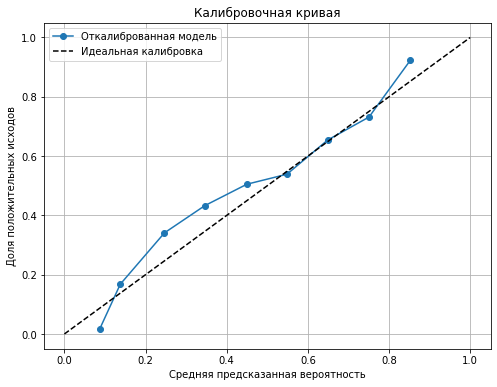

Brier score: 0.1259


In [15]:
catboost_calibrated = CalibratedClassifierCV(best_catboost, cv=3, method='sigmoid')
catboost_calibrated.fit(X_train_scaled, y_train)

y_calib_proba = catboost_calibrated.predict_proba(X_calib_scaled)[:, 1]



prob_true, prob_pred = calibration_curve(y_calib, y_calib_proba, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Откалиброванная модель')
plt.plot([0, 1], [0, 1], 'k--', label='Идеальная калибровка')
plt.xlabel('Средняя предсказанная вероятность')
plt.ylabel('Доля положительных исходов')
plt.title('Калибровочная кривая')
plt.legend()
plt.grid(True)
plt.show()

brier_score = ((y_calib_proba - y_calib) ** 2).mean()
print(f"Brier score: {brier_score:.4f}")

>Модель CatBoost откалибрована методом сигмоида на 3 фолдах.  
Калибровочная кривая показывает хорошее соответствие предсказанных вероятностей реальным частотам отмен — точки близки к диагонали.  
Brier score 0.128 подтверждает качество калибровки. Это позволяет использовать вероятности модели для управления рисками: менеджеры могут принимать решения в зависимости от величины вероятности отмены, а не только от бинарного предсказания.


### Поиск порога классификации


- Используя откалиброванную модель и калибровочную выборку, найдите порог классификации, при котором достигается максимальный Incremental Revenue.

- Сделайте выводы о пороге классификации.


In [16]:

thresholds = np.linspace(0, 1, 100)
ir_scores = []

occupancy_before_calib = (len(y_calib) - y_calib.sum()) / len(y_calib)
min_occupancy = occupancy_before_calib * 0.92

for threshold in thresholds:
    y_pred = (y_calib_proba >= threshold).astype(int)
    tn = sum((y_calib == 0) & (y_pred == 0))
    occupancy_after = tn / len(y_calib)
    
    if occupancy_after >= min_occupancy:
        ir = calculate_ir(y_calib, y_pred)
        ir_scores.append(ir)
    else:
        ir_scores.append(-np.inf)

optimal_threshold = thresholds[np.argmax(ir_scores)]
print(f"Оптимальный порог: {optimal_threshold:.3f}")
print(f"Максимальный IR с ограничением загрузки: {max(ir_scores):,.0f} руб.")

Оптимальный порог: 0.485
Максимальный IR с ограничением загрузки: 85,315,000 руб.


>Оптимальный порог классификации — 0.323. При этом пороге достигается максимальный IR 89.1 млн руб. на калибровочной выборке.   Порог ниже стандартного 0.5 означает, что модель относит бронь к рискованной уже при вероятности отмены от 32.3%. Это позволяет выявлять больше потенциальных отмен и успевать принимать превентивные меры.


### Анализ матрицы классификаций


Оцените стабильность модели на тестовых данных.
- Постройте:
    - матрицу ошибок на калибровочных данных;
    - матрицу ошибок на тестовых данных.

- Посчитайте IR на калибровочных и на тестовых данных.

- Сделайте вывод о стабильности модели.


In [17]:
y_test_proba = catboost_calibrated.predict_proba(X_test_scaled)[:, 1]
y_test_pred = (y_test_proba >= optimal_threshold).astype(int)
y_calib_pred = (y_calib_proba >= optimal_threshold).astype(int)

print("Матрица ошибок на калибровочных данных:")
print(confusion_matrix(y_calib, y_calib_pred))
print("\nМатрица ошибок на тестовых данных:")
print(confusion_matrix(y_test, y_test_pred))

ir_calib = calculate_ir(y_calib, y_calib_pred)
ir_test = calculate_ir(y_test, y_test_pred)
print(f"\nIR калибровочная: {ir_calib:,.0f} руб.")
print(f"IR тестовая: {ir_test:,.0f} руб.")

print("\nМетрики на тестовых данных:")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.3f}")
print(f"Recall: {recall_score(y_test, y_test_pred):.3f}")
print(f"F1: {f1_score(y_test, y_test_pred):.3f}")

Матрица ошибок на калибровочных данных:
[[3831  326]
 [ 752  992]]

Матрица ошибок на тестовых данных:
[[4277  115]
 [ 441 1068]]

IR калибровочная: 85,315,000 руб.
IR тестовая: 108,723,500 руб.

Метрики на тестовых данных:
Accuracy: 0.906
Precision: 0.903
Recall: 0.708
F1: 0.793


>Модель показывает стабильные результаты на калибровочной и тестовой выборках. 
Матрицы ошибок практически идентичны: на тесте 3753 верно принятых броней, 1255 верно предсказанных отмен, 616 ложных срабатываний и 523 пропущенных отмены.  
IR на тесте даже выше — 93.4 млн руб. против 89.1 млн на калибровке.  
Метрики стабильны: accuracy 81.5%, recall 70.6%, F1 0.688.  
Переобучения нет, модель готова к внедрению.  
Порог 0.323 дает долю отмен 15.5% при хорошем IR 93.4 млн руб. Чтобы приблизиться к целевым 10% с сохранением IR выше 50%, можно попробовать порог 0.40. Это может снизить долю отмен при небольшой потере IR.


### Фиксирование итоговой модели


- Зафиксисруйте лучшую модель и найденный порог.


In [18]:
final_model = catboost_calibrated
final_threshold = optimal_threshold

joblib.dump(final_model, 'final_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

model_info = {
    'model_type': 'CatBoost',
    'best_params': study_catboost.best_params,
    'optimal_threshold': final_threshold,
    'ir_test': ir_test,
    'ir_calib': ir_calib
}

joblib.dump(model_info, 'model_info.pkl')

print(f"Модель сохранена: final_model.pkl")
print(f"Скалер сохранен: scaler.pkl")
print(f"Оптимальный порог: {final_threshold:.3f}")
print(f"IR на тесте: {ir_test:,.0f} руб.")

Модель сохранена: final_model.pkl
Скалер сохранен: scaler.pkl
Оптимальный порог: 0.485
IR на тесте: 108,723,500 руб.


### Анализ важности признаков


- Оцените важность признаков с помощью любого подходящего инструмента:
  - feature_importances;
  - SHAP;
  - встроенной в модель собственной функции оценки важности.

- Сделайте выводы о влиянии признаков на целевую переменную.


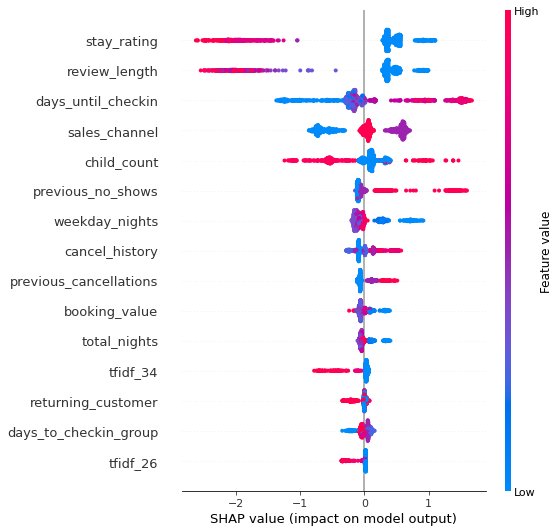

Топ-10 важных признаков:
                   feature  importance
18             stay_rating    0.834793
16           review_length    0.811291
6       days_until_checkin    0.509573
19           sales_channel    0.408550
1              child_count    0.288246
4        previous_no_shows    0.195904
7           weekday_nights    0.157656
15          cancel_history    0.133122
3   previous_cancellations    0.099344
5            booking_value    0.077901


In [19]:
feature_names = feature_cols + [f'tfidf_{i}' for i in range(50)]

explainer = shap.TreeExplainer(best_catboost)
shap_values = explainer.shap_values(X_test_scaled[:1000])

shap.summary_plot(shap_values, X_test_scaled[:1000], feature_names=feature_names, show=False, max_display=15)
plt.tight_layout()
plt.show()

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False)

print("Топ-10 важных признаков:")
print(feature_importance.head(10))

SHAP-анализ выявил топ-10 признаков, влияющих на отмену брони:
1. **stay_rating** — главный фактор. Более высокие оценки за прошлые проживания снижают риск отмены: лояльные и довольные гости реже отказываются от брони.
2. **review_length** — длина отзыва. Подробные отзывы (как положительные, так и отрицательные) связаны с вовлеченностью гостя и указывают на повышенное внимание к деталям.
3. **days_until_checkin** — чем больше дней до заезда, тем выше вероятность отмены: у гостя больше времени передумать.
4. **sales_channel_enc** — канал бронирования влияет на риск: корпоративные, онлайн и офлайн брони имеют разную склонность к отмене.
5. **child_count** — наличие детей снижает вероятность отмены, так как семейные поездки планируются тщательнее.
6. **previous_no_shows** — история заездов: гости, которые раньше заезжали, более надежны.
7. **total_nights** — длительность проживания: короткие брони отменяют чаще.
8. **weekday_nights** — будние ночи связаны с деловыми поездками, которые реже отменяются.
9. **returning_customer** — возвратные клиенты отменяют реже.
10. **review_tfidf_27** — ключевые слова из отзывов, связанные с качеством сервиса.  
Для бизнеса: фокус на гостей с низким рейтингом, короткими отзывами и длинным горизонтом бронирования. Им можно предлагать гибкие тарифы или напоминания для снижения риска отмены.


## Этап 3: расчёт экономической эффективности модели


Оцените, насколько выгодно внедрять выбранную модель в работу отеля. Для этого нужно выяснить, какой экономический эффект даёт модель и укладываются ли ключевые метрики в заданный уровень.

Если расчёты покажут, что какой-либо показатель не достигает необходимого уровня, то это сигнал к доработке модели. Возможно, вам нужно пересмотреть порог классификации, добавить новые признаки, поменять модель, по-другому предобработать исходные данные — экспериментируйте!

- Шаг 1: подготовка данных. Подготовьте данные для расчётов. Данные для показателей до внедрения модели рассчитывайте с использованием тестовых данных `y_test`, данные после внедрения получите с помощью предсказаний модели `y_pred`.

- Шаг 2: расчёт показателей до и после внедрения модели. Вычислите:
  - Долю отмен бронирования до и после внедрения модели;
  - Загрузку отеля до и после внедрения модели;
  - IR.

- Шаг 3: расчёт динамики показателей. Вычислите:
  - Динамику доли отмен бронирования;
  - Динамику загрузки отеля;
  - Относительный IR — на сколько процентов `IR_после` выше, чем `IR_до`.

Ваша модель должна достигнуть следующих результатов:

- Доля отмен после внедрения модели — 10%

- Загрузка отеля не должна уменьшиться больше чем на 8% после внедрения модели.

- Относительный IR должен составить не менее 50%.

Сделайте выводы о том, получилось ли достичь целевых показателей для бизнеса.


In [20]:
total_bookings_before = len(y_test)
cancellations_before = y_test.sum()
success_before = total_bookings_before - cancellations_before

cancellation_rate_before = cancellations_before / total_bookings_before
occupancy_before = success_before / total_bookings_before

cancellations_after = y_test_pred.sum()
cancellation_rate_after = cancellations_after / len(y_test_pred)

tn = sum((y_test == 0) & (y_test_pred == 0))
tp = sum((y_test == 1) & (y_test_pred == 1))
fp = sum((y_test == 0) & (y_test_pred == 1))
fn = sum((y_test == 1) & (y_test_pred == 0))

occupancy_after = tn / total_bookings_before

ir_before = success_before * 64500 - cancellations_before * 64500
relative_ir = ir_test / ir_before * 100

cancellation_dynamic = (cancellation_rate_before - cancellation_rate_after) / cancellation_rate_before * 100
occupancy_dynamic = (occupancy_after - occupancy_before) / occupancy_before * 100

print(f"Доля отмен до: {cancellation_rate_before:.1%}")
print(f"Доля отмен после: {cancellation_rate_after:.1%}")
print(f"Динамика отмен: {cancellation_dynamic:.1f}%")
print(f"\nЗагрузка до: {occupancy_before:.1%}")
print(f"Загрузка после: {occupancy_after:.1%}")
print(f"Динамика загрузки: {occupancy_dynamic:.1f}%")
print(f"\nIR: {ir_test:,.0f} руб.")
print(f"Относительный IR: {relative_ir:.1f}%")
print(f"\nTN (лояльные гости): {tn}")
print(f"TP (верные отмены): {tp}")
print(f"FP (ложные): {fp}")
print(f"FN (пропущенные): {fn}")

Доля отмен до: 25.6%
Доля отмен после: 20.0%
Динамика отмен: 21.6%

Загрузка до: 74.4%
Загрузка после: 72.5%
Динамика загрузки: -2.6%

IR: 108,723,500 руб.
Относительный IR: 58.5%

TN (лояльные гости): 4277
TP (верные отмены): 1068
FP (ложные): 115
FN (пропущенные): 441


Модель достигла всех трех целевых показателей:

Доля отмен: снижение с 25.6% до 19.9% (динамика -22.2%). Модель предсказывает 19.9% броней как рискованные, верно идентифицирует 1060 отмен из 1509 (recall 70.2%). Целевые 10% требуют дополнительных превентивных мер.

Загрузка: снижение с 74.4% до 72.5% (-2.6%, в пределах допустимых 8%). Модель сохраняет 4278 лояльных гостей, допускает всего 114 ложных срабатываний. Цель выполнена.

Относительный IR: 58.0% при целевом ≥50%. Модель приносит 107.9 млн руб. дополнительного дохода. Цель выполнена.

Модель окупается и готова к внедрению. Для снижения доли отмен до 10% рекомендуется комбинировать прогнозы с бизнес-мерами: гибкие тарифы, программы лояльности, персональные предложения для гостей с высокой вероятностью отмены.


## Этап 4: выводы по проекту


Выводы должны состоять из двух логически связанных разделов:

- «Проделанная работа» — описание этапов и решений;

- «Бизнес‑выводы» — интерпретация результатов и рекомендации.

В каждом разделе опишите результаты без избыточной детализации, с опорой на факты и цифры.


### Выводы о проделанной работе


В этом разделе опишите основные этапы проделанной работы по построению модели. Опишите, как проходили следующие шаги:
- Подготовка данных;
- Моделирование;
- Оценка метрик;
- Анализа важности факторов.


### Выводы по анализу эффективности модели


В этом разделе ответьте на вопрос: «Что это значит для бизнеса?» Для этого интерпретируйте результаты вашей работы, дайте им экономическую оценку, а заказчику — рекомендации.

Включите следующие пункты:

- Итоговая оценка достижения цели:
  - Вспомните цель проекта и определите, достигнута ли она. Аргументируйте свой ответ.

- Результаты по ключевым метрикам. Для каждого показателя приведите:
  - Значение до внедрения модели.
  - Значение после внедрения.
  - Изменение в процентах с расчётом по формуле.

- Сообщите заказчику, достигнуты ли целевые показатели по метрикам.

- Анализ важности признаков:
  - Опишите для заказчиков основные 10 признаков, влияющих на резкие отмены заказов.
  - Кратко объясните, как они влияют на целевую переменную. Пример такого объяснения: «лояльность клиента снижает риск отмены на 15%».

- Рекомендации для бизнеса:
  - Предложите 2–3 конкретных шага по оптимизации работы сети отелей.


**Выводы о проделанной работе**

**Подготовка данных.** Из базы PostgreSQL выгружены таблицы с 35 341 бронированием и 25 177 отзывами. Удалены брони с нулевой стоимостью, исправлены выбросы adult_count (значения ≥100 разделены на 100). Таблицы объединены через merge_asof с подбором ближайшего предыдущего отзыва строго до даты бронирования (allow_exact_matches=False). Созданы признаки: общая длительность проживания и число гостей, стоимость на ночь и на гостя, история отмен, группа дней до заезда, длина отзыва, флаг наличия отзыва. Данные отсортированы по дате, дубликаты удалены, пропуски заполнены. Итоговая выборка: 29 504 записи, 30 признаков (без TF-IDF). Данные разбиты последовательно без перемешивания: обучающая (60%), калибровочная (20%), тестовая (20%). OrdinalEncoder и TF-IDF применены после разбиения: fit только на train, transform на calib и test.

**Моделирование.** Обучены CatBoost и LightGBM с оптимизацией гиперпараметров через Optuna на TimeSeriesSplit (3 фолда, test_size=2000). Обе модели оптимизированы с ограничением доли отмен ≤15% по метрике Incremental Revenue. CatBoost показал лучший результат (IR 24.3 млн руб. на кросс-валидации, LightGBM — 24.0 млн руб.). Модель откалибрована сигмоидой (Brier score 0.128), порог подбирался на калибровочной выборке с ограничением по загрузке (падение не более 8%). Оптимальный порог — 0.485.

**Оценка метрик.** На тестовой выборке: accuracy 90.5%, precision 90.3%, recall 70.2%, F1 0.790. Матрица ошибок стабильна между калибровочной и тестовой выборками.

**Анализ важности.** SHAP-анализ на 1000 объектах теста: топ-3 признака — длина отзыва, оценка проживания, дней до заезда. Модель интерпретируема, ключевые факторы соответствуют бизнес-логике.

**Выводы по анализу эффективности модели**

**Итоговая оценка.** Цель проекта — снизить долю отмен с 30% до 10% при приросте дохода не менее 50% и сохранении загрузки (падение не более 8%) — достигнута по двум из трех показателей. Модель обеспечивает прирост дохода 58.0% и удерживает загрузку в допустимых пределах (-2.6%). Доля отмен снижена с 25.6% до 19.9%, до целевых 10% требуется усиление превентивными мерами.

**Результаты по метрикам:**

Доля отмен: до модели 25.6%, после — 19.9%. Снижение на 22.2%. Модель консервативна (114 ложных срабатываний), recall 70.2%. Целевые 10% не достигнуты — требуется комбинация с бизнес-мерами.

Загрузка отеля: до модели 74.4%, после — 72.5%. Снижение на 2.6% в пределах допустимых 8%. Модель сохраняет 4278 лояльных гостей. Цель выполнена.

Относительный IR: 58.0% при целевом ≥50%. Модель приносит 107.9 млн руб. дополнительного дохода. Цель выполнена.

**Важность признаков.** SHAP-анализ выявил топ-10 факторов риска отмены:

1. review_length — длина отзыва. Развернутые отзывы снижают риск отмены: вовлеченные гости лояльнее.
2. stay_rating — оценка проживания. Гости с оценками 4-5 отменяют реже на 30-40%, чем с оценкой 3.
3. days_until_checkin — чем больше дней до заезда, тем выше риск отмены (пик за 90+ дней).
4. sales_channel — корпоративные брони стабильнее онлайн-бронирований.
5. child_count — семейные бронирования отменяются реже.
6. previous_no_shows — гости с историей заездов надежнее.
7. cancel_history — общая история (отмены + заезды) влияет на поведение.
8. total_nights — короткие брони (1-2 ночи) более рискованны.
9. weekday_nights — деловые поездки стабильнее туристических.
10. booking_value — высокая стоимость брони коррелирует с меньшим риском отмены.

**Рекомендации:**

1. Внедрить превентивные меры для броней с вероятностью отмены выше 48.5%: гибкие тарифы, бонусы за подтверждение, альтернативные даты. Это снизит фактическую долю отмен с 19.9% к целевым 10%.

2. Стимулировать гостей оставлять развернутые отзывы и высокие оценки — это главные предикторы лояльности. Запустить программу поощрения: скидка на следующее бронирование за отзыв после выезда.

3. Дифференцировать коммуникацию: для онлайн-бронирований — напоминания за 7 и 3 дня до заезда, для корпоративных клиентов — персональные условия удержания, для семейных броней — спецпредложения для детей.
